In [ ]:
from reservoirpy.datasets import lorenz, rossler, logistic_map
from rcpy.data.data_generation import ulam_map
from rcpy.data import preprocess_data_rcpy 
import json
import numpy as np

# ================================
# 1. DATA
# ================================
#system = "nino_1870_2024"
system = "logistic_map"
r = 3.8
system_name = f"{system}_r{r}"

# ----- Generate or load raw data -----
#data_raw = logistic_map(n_timesteps=10000, r=3.8, x0=0.5)
#data_raw = ulam_map(x0=0.1, n_steps=10000, discard=3000)
#data_raw = lorenz(10000)
#data_raw = rossler(11000)[1000:,0]
#data_raw = np.load(f"../../../data/generated/ts_{system}.npy")
data_raw = np.loadtxt(f"../../../data/enso/ts_{system_name}.npy")


# ----- Preprocess data -----

offset = 0
train_length = 6000
val_length = 1000

data = preprocess_data_rcpy(
    data=data_raw,
    init_discard=offset,
    train_length=train_length,
    val_length=val_length,
    normalize=True
)

# ================================
# 2. HYPERPARAMETERS
# ================================

# ----- Load  -----
filename = f"esn_hypopt_study_best_params.json"
with open(filename, "r") as file:
    params = json.load(file)

reservoir_units = params['reservoir_units']
seed = params['seed']
leak_rate = params['leak_rate']
spectral_radius = params['spectral_radius']
input_scaling = params['input_scaling']
alpha = params['alpha']
p = params['p']

# ----- Manual input -----
#seed = np.random.randint(0, 10000)  # Random seed for reproducibility
""" seed = 42
reservoir_units = 200
spectral_radius = 0.9
leak_rate = 0.75
input_scaling = 1
alpha = 1e-7
p = 0.1 """

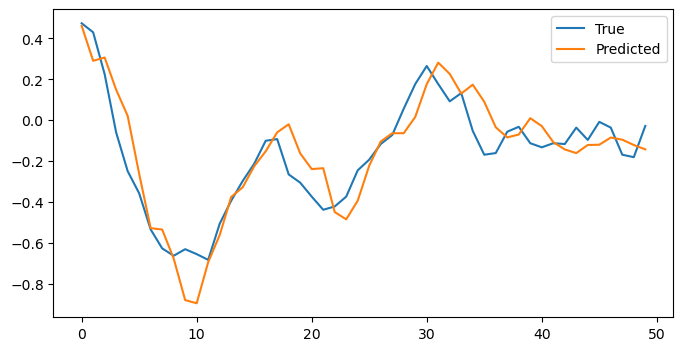

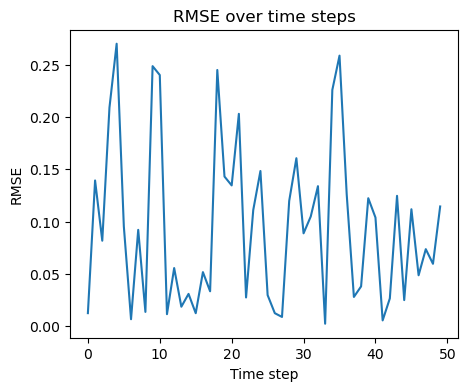

In [ ]:
from rcpy.models import create_model
from rcpy.training import train_model
from rcpy.forecasting import forecast_rcpy
from rcpy.analysis import compute_skill
import matplotlib.pyplot as plt
from rcpy.plotting import plot_forecast

hyperparams = {
    'reservoir_units': reservoir_units,
    'leak_rate': leak_rate,
    'spectral_radius': spectral_radius,
    'input_scaling': input_scaling,
    'alpha': alpha,
    'p': p,
    'seed': seed
}


# ================================
# 3a. RESERVOIR
# ================================

# ----- Create model -----
model = create_model(hyperparams=hyperparams, output_dim=data['train_data'].shape[1])

# ----- Train model -----
washout_training = 500
trained_model = train_model(model=model, train_data=data['train_data'], forecasting_step=1, washout_training=washout_training)


# ================================
# 4a. FORECASTING
# ================================
warmup_length = 1000
warmup_data=data['val_data'][-warmup_length:]

forecast_length = 1000

Y_pred = forecast_rcpy(model=trained_model,
                        warmup_data=warmup_data,
                        forecast_length=forecast_length,
                        mode="teacher_forced",
                        forecast_data=data["test_data"],
                        reset=True)
#Y_true = data["val_data"][:forecast_length]

# ================================
# 5a. PERFORMANCE
# ================================
Y_true = data["test_data"][1:forecast_length+1]
#Y_true = data["test_data"][:forecast_length]

rmse = compute_skill(y_true=Y_true, y_pred=Y_pred, method='error', mode="per_step")

# Plotting results
plot_length = 50

plt.figure(figsize=(8, 4))
plt.plot(Y_true[:plot_length], label='True')
plt.plot(Y_pred[:plot_length], label='Predicted')
plt.legend()
plt.show()

fig = plt.figure(figsize=(5, 4))
fig = plt.plot(rmse[:plot_length])
plt.xlabel("Time step")
plt.ylabel("RMSE")
plt.title("RMSE over time steps")
plt.show()

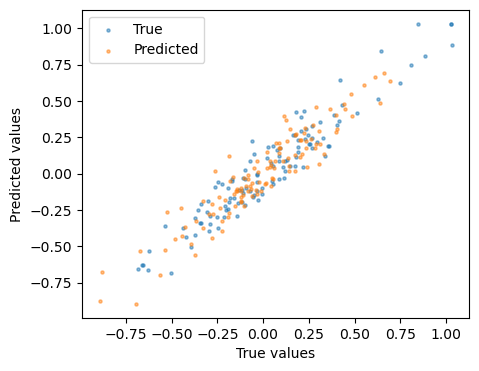

In [8]:
tau = 1

plt.figure(figsize=(5, 4))
plt.scatter(Y_true[tau:], Y_true[:-tau], s=5, label='True', alpha=0.5)
plt.scatter(Y_pred[tau:], Y_pred[:-tau], s=5, label='Predicted', alpha=0.5)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.legend()